# **STAT GR5291 - Final Project**

## **ML Signal Design: AdaBoost & LSTM**



# **1. Model 1 : AdaBoost**

In [ ]:
!pip install yfinance pykalman pandas numpy matplotlib seaborn scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

## **1.1 Acquire data from Yahoo Finance**

In [29]:
pair1_y = 'KO'
pair1_x = 'PEP'
pair2_y = 'XOM'
pair2_x = 'CVX'

start_date = '2015-01-01'
end_date = '2026-01-01'

data = yf.download([pair1_y, pair1_x, pair2_y, pair2_x],
                   start=start_date, end=end_date,
                   auto_adjust=False)['Adj Close']

# Censor missing data
data = data.dropna()

print(f"Shape of data set: {data.shape}")
print(f"Range of date: {data.index[0]} to {data.index[-1]}")
print(data.head())

[*********************100%***********************]  4 of 4 completed

Shape of data set: (2766, 4)
Range of date: 2015-01-02 00:00:00 to 2025-12-31 00:00:00
Ticker            CVX         KO        PEP        XOM
Date                                                  
2015-01-02  69.529388  29.580009  67.283470  57.533421
2015-01-05  66.750214  29.580009  66.777618  55.959206
2015-01-06  66.719292  29.804630  66.271812  55.661713
2015-01-07  66.663727  30.176664  68.209648  56.225708
2015-01-08  68.189201  30.541674  69.449303  57.161552


## **1.2 Compute log(price) and log(yield)**

In [30]:
log_prices = np.log(data)

log_returns = log_prices.diff().dropna()

print(log_prices.head())
print(log_returns.head())

Ticker           CVX        KO       PEP       XOM
Date                                              
2015-01-02  4.241750  3.387099  4.208915  4.052366
2015-01-05  4.200957  3.387099  4.201368  4.024623
2015-01-06  4.200494  3.394664  4.193765  4.019293
2015-01-07  4.199661  3.407069  4.222586  4.029374
2015-01-08  4.222286  3.419092  4.240597  4.045882
Ticker           CVX        KO       PEP       XOM
Date                                              
2015-01-05 -0.040792  0.000000 -0.007547 -0.027743
2015-01-06 -0.000463  0.007565 -0.007603 -0.005330
2015-01-07 -0.000833  0.012405  0.028821  0.010082
2015-01-08  0.022625  0.012023  0.018011  0.016507
2015-01-09 -0.020127 -0.011093 -0.006794 -0.001410


## **1.3 Calculate static spreads and Z-scores using rolling OLS**

In [31]:
def calculate_ols_spread_and_zscore(y, x, lookback=252):
    spread = pd.Series(index=y.index, dtype=float)
    beta = pd.Series(index=y.index, dtype=float)
    alpha = pd.Series(index=y.index, dtype=float)

    for i in range(lookback, len(y)):
        y_window = y.iloc[i-lookback:i]
        x_window = x.iloc[i-lookback:i]

        X = np.column_stack([np.ones(len(x_window)), x_window.values])
        Y = y_window.values

        # calculate beta and alpha
        coeffs = np.linalg.lstsq(X, Y, rcond=None)[0]
        alpha.iloc[i] = coeffs[0]
        beta.iloc[i] = coeffs[1]

        # calculate current spread
        spread.iloc[i] = y.iloc[i] - (coeffs[0] + coeffs[1] * x.iloc[i])

    # compute z-score
    zscore = pd.Series(index=y.index, dtype=float)
    for i in range(lookback + lookback, len(y)):
        spread_window = spread.iloc[i-lookback:i]
        if spread_window.std() > 0:
            zscore.iloc[i] = (spread.iloc[i] - spread_window.mean()) / spread_window.std()

    return spread, zscore, beta, alpha

spread_ols_ko_pep, zscore_ols_ko_pep, beta_ols_ko_pep, alpha_ols_ko_pep = calculate_ols_spread_and_zscore(
    log_prices['KO'], log_prices['PEP']
)

spread_ols_xom_cvx, zscore_ols_xom_cvx, beta_ols_xom_cvx, alpha_ols_xom_cvx = calculate_ols_spread_and_zscore(
    log_prices['XOM'], log_prices['CVX']
)

print(f"KO-PEP z-score:\n{zscore_ols_ko_pep.tail()}")

KO-PEP z-score:
Date
2025-12-24   -0.416917
2025-12-26   -0.522759
2025-12-29   -0.416295
2025-12-30   -0.468574
2025-12-31   -0.558895
dtype: float64


## **1.4 Calculating Dynamic Spreads and Z-Scores Using Kalman Filtering**

In [33]:
from pykalman import KalmanFilter

def calculate_kalman_spread_and_zscore(y, x, lookback=252):


    kf = KalmanFilter(
        transition_matrices=np.eye(2),
        observation_matrices=np.zeros((1, 2)),
        initial_state_mean=[0, 1],
        initial_state_covariance=np.eye(2),
        transition_covariance=0.0001 * np.eye(2),
        observation_covariance=0.01
    )


    alpha_kf = pd.Series(index=y.index, dtype=float)
    beta_kf = pd.Series(index=y.index, dtype=float)

    state_mean = np.array([0.0, 1.0])
    state_cov = np.eye(2)

    for i in range(len(y)):
        if i == 0:
            alpha_kf.iloc[i] = state_mean[0]
            beta_kf.iloc[i] = state_mean[1]
            continue


        obs_matrix = np.array([[1.0, x.iloc[i]]])


        state_mean_pred = state_mean
        state_cov_pred = state_cov + 0.0001 * np.eye(2)


        y_obs = y.iloc[i]
        y_pred = obs_matrix @ state_mean_pred
        innovation = y_obs - y_pred

        S = obs_matrix @ state_cov_pred @ obs_matrix.T + 0.01
        K = state_cov_pred @ obs_matrix.T / S

        state_mean = state_mean_pred + K.flatten() * innovation
        state_cov = state_cov_pred - np.outer(K, obs_matrix @ state_cov_pred)

        alpha_kf.iloc[i] = state_mean[0]
        beta_kf.iloc[i] = state_mean[1]

    # compute Kalman spread
    spread_kf = y - (alpha_kf + beta_kf * x)

    # compute z-score
    zscore_kf = pd.Series(index=y.index, dtype=float)
    for i in range(lookback, len(y)):
        spread_window = spread_kf.iloc[i-lookback:i]
        if spread_window.std() > 0:
            zscore_kf.iloc[i] = (spread_kf.iloc[i] - spread_window.mean()) / spread_window.std()

    return spread_kf, zscore_kf, beta_kf, alpha_kf

spread_kf_ko_pep, zscore_kf_ko_pep, beta_kf_ko_pep, alpha_kf_ko_pep = calculate_kalman_spread_and_zscore(
    log_prices['KO'], log_prices['PEP']
)

spread_kf_xom_cvx, zscore_kf_xom_cvx, beta_kf_xom_cvx, alpha_kf_xom_cvx = calculate_kalman_spread_and_zscore(
    log_prices['XOM'], log_prices['CVX']
)


## **1.5 Calculate rolling statistical features**

In [35]:
def calculate_rolling_features(spread, zscore, log_returns_y, log_returns_x, window=20):

    features = pd.DataFrame(index=spread.index)

    # current spread and zscore
    features['spread'] = spread
    features['zscore'] = zscore

    # lag z-score（1day、3days、5days）
    features['zscore_lag1'] = zscore.shift(1)
    features['zscore_lag3'] = zscore.shift(3)
    features['zscore_lag5'] = zscore.shift(5)

    # z-score dynamic
    features['delta_zscore'] = zscore - zscore.shift(1)

    features['spread_volatility'] = spread.rolling(window).std()

    # rolling ADF p-value（
    def rolling_autocorr(series, window=20):
        autocorr = pd.Series(index=series.index, dtype=float)
        for i in range(window, len(series)):
            autocorr.iloc[i] = series.iloc[i-window:i].autocorr(lag=1)
        return autocorr

    features['spread_autocorr'] = rolling_autocorr(spread, window)

    def rolling_corr(s1, s2, window=20):
        corr = pd.Series(index=s1.index, dtype=float)
        for i in range(window, len(s1)):
            corr.iloc[i] = s1.iloc[i-window:i].corr(s2.iloc[i-window:i])
        return corr

    features['return_correlation'] = rolling_corr(log_returns_y, log_returns_x, window)

    return features


features_ols_ko_pep = calculate_rolling_features(
    spread_ols_ko_pep, zscore_ols_ko_pep,
    log_returns['KO'], log_returns['PEP']
)
features_kf_ko_pep = calculate_rolling_features(
    spread_kf_ko_pep, zscore_kf_ko_pep,
    log_returns['KO'], log_returns['PEP']
)
features_ols_xom_cvx = calculate_rolling_features(
    spread_ols_xom_cvx, zscore_ols_xom_cvx,
    log_returns['XOM'], log_returns['CVX']
)
features_kf_xom_cvx = calculate_rolling_features(
    spread_kf_xom_cvx, zscore_kf_xom_cvx,
    log_returns['XOM'], log_returns['CVX']
)

print(f"OLS KO-PEP shape: {features_ols_ko_pep.shape}")
print(features_ols_ko_pep.columns.tolist())

OLS KO-PEP shape: (2766, 9)
['spread', 'zscore', 'zscore_lag1', 'zscore_lag3', 'zscore_lag5', 'delta_zscore', 'spread_volatility', 'spread_autocorr', 'return_correlation']


## **1.6 Create label**

$$Y_t = \mathbf{1} \{ |z_{t+h}| < |z_t| \}, h = 5$$

In [36]:
def create_labels(zscore, horizon=5):

    labels = pd.Series(index=zscore.index, dtype=float)

    for i in range(len(zscore) - horizon):
        current_z = zscore.iloc[i]
        future_z = zscore.iloc[i + horizon]

        if abs(future_z) < abs(current_z):
            labels.iloc[i] = 1
        else:
            labels.iloc[i] = 0

    return labels


labels_ols_ko_pep = create_labels(zscore_ols_ko_pep)
labels_kf_ko_pep = create_labels(zscore_kf_ko_pep)
labels_ols_xom_cvx = create_labels(zscore_ols_xom_cvx)
labels_kf_xom_cvx = create_labels(zscore_kf_xom_cvx)


print(f"label distribution (OLS KO-PEP):\n{labels_ols_ko_pep.value_counts()}")
print(f"Mean-reversion ratio: {labels_ols_ko_pep.mean():.3f}")

label distribution (OLS KO-PEP):
0.0    1592
1.0    1169
Name: count, dtype: int64
Mean-reversion ratio: 0.423


## **1.7 Retain only the moments when trading signals are present, filtering out outliers**

The ML filter only intervenes when the z-score reaches an extreme value.
 - retain |z| > 1.5

In [39]:
def filter_entry_signals(features, labels, zscore, entry_threshold=2.0):

    signal_mask = abs(zscore) > entry_threshold

    filtered_features = features[signal_mask].copy()
    filtered_labels = labels[signal_mask].copy()

    return filtered_features, filtered_labels

print(f"(OLS KO-PEP): {len(features_ols_ko_pep)}")


def prepare_dataset(features, labels, zscore):
    df = features.copy()
    df['label'] = labels
    df = df.dropna()
    return df


data_ols_ko_pep = prepare_dataset(features_ols_ko_pep, labels_ols_ko_pep, zscore_ols_ko_pep)
data_kf_ko_pep = prepare_dataset(features_kf_ko_pep, labels_kf_ko_pep, zscore_kf_ko_pep)
data_ols_xom_cvx = prepare_dataset(features_ols_xom_cvx, labels_ols_xom_cvx, zscore_ols_xom_cvx)
data_kf_xom_cvx = prepare_dataset(features_kf_xom_cvx, labels_kf_xom_cvx, zscore_kf_xom_cvx)


entry_threshold = 1.5

print("（entry_threshold =", entry_threshold, "）...")

# OLS KO-PEP
signal_mask_ols_ko = abs(data_ols_ko_pep['zscore']) > entry_threshold
data_ols_ko_pep_signals = data_ols_ko_pep[signal_mask_ols_ko].copy()

# Kalman KO-PEP
signal_mask_kf_ko = abs(data_kf_ko_pep['zscore']) > entry_threshold
data_kf_ko_pep_signals = data_kf_ko_pep[signal_mask_kf_ko].copy()

# OLS XOM-CVX
signal_mask_ols_xom = abs(data_ols_xom_cvx['zscore']) > entry_threshold
data_ols_xom_cvx_signals = data_ols_xom_cvx[signal_mask_ols_xom].copy()

# Kalman XOM-CVX
signal_mask_kf_xom = abs(data_kf_xom_cvx['zscore']) > entry_threshold
data_kf_xom_cvx_signals = data_kf_xom_cvx[signal_mask_kf_xom].copy()

print(f"(OLS KO-PEP): {len(data_ols_ko_pep_signals)}")
print(f"(KF KO-PEP): {len(data_kf_ko_pep_signals)}")
print(f"(OLS XOM-CVX): {len(data_ols_xom_cvx_signals)}")
print(f"(KF XOM-CVX): {len(data_kf_xom_cvx_signals)}")
print(f"(OLS KO-PEP):\n{data_ols_ko_pep_signals['label'].value_counts()}")

(OLS KO-PEP): 2766
（entry_threshold = 1.5 ）...
(OLS KO-PEP): 593
(KF KO-PEP): 316
(OLS XOM-CVX): 539
(KF XOM-CVX): 281
(OLS KO-PEP):
label
1.0    392
0.0    201
Name: count, dtype: int64


## **1.8 Split the data into training, validation, and test sets**

 - training set：2015-2020
 - validation set：2021-2022
 - testing set：2023-2026.01.01

In [40]:
train_end = '2020-12-31'
val_end = '2022-12-31'

def split_data_by_date(df):
    train = df[df.index <= train_end]
    val = df[(df.index > train_end) & (df.index <= val_end)]
    test = df[df.index > val_end]
    return train, val, test


train_ols_ko, val_ols_ko, test_ols_ko = split_data_by_date(data_ols_ko_pep_signals)
train_kf_ko, val_kf_ko, test_kf_ko = split_data_by_date(data_kf_ko_pep_signals)
train_ols_xom, val_ols_xom, test_ols_xom = split_data_by_date(data_ols_xom_cvx_signals)
train_kf_xom, val_kf_xom, test_kf_xom = split_data_by_date(data_kf_xom_cvx_signals)

print(f" (OLS KO-PEP): {len(train_ols_ko)}")
print(f" (OLS KO-PEP): {len(val_ols_ko)}")
print(f" (OLS KO-PEP): {len(test_ols_ko)}")

 (OLS KO-PEP): 260
 (OLS KO-PEP): 115
 (OLS KO-PEP): 218


## **1.9 Prepare the feature matrix**

In [41]:
feature_columns = ['spread', 'zscore', 'zscore_lag1', 'zscore_lag3', 'zscore_lag5',
                   'delta_zscore', 'spread_volatility', 'spread_autocorr', 'return_correlation']

def prepare_X_y(data, feature_cols):

    X = data[feature_cols].values
    y = data['label'].values
    return X, y


X_train_ols_ko, y_train_ols_ko = prepare_X_y(train_ols_ko, feature_columns)
X_val_ols_ko, y_val_ols_ko = prepare_X_y(val_ols_ko, feature_columns)
X_test_ols_ko, y_test_ols_ko = prepare_X_y(test_ols_ko, feature_columns)


scaler_ols_ko = StandardScaler()
X_train_ols_ko = scaler_ols_ko.fit_transform(X_train_ols_ko)
X_val_ols_ko = scaler_ols_ko.transform(X_val_ols_ko)
X_test_ols_ko = scaler_ols_ko.transform(X_test_ols_ko)

print(f"shape of the feature matrix - training set: {X_train_ols_ko.shape}")
print(f"label distrubution - training set: regression={y_train_ols_ko.sum()}, non-regresstion={len(y_train_ols_ko)-y_train_ols_ko.sum()}")

shape of the feature matrix - training set: (260, 9)
label distrubution - training set: regression=177.0, non-regresstion=83.0


## **1.10 AdaBoost Model training**

 - Train OLS KO-PEP:

In [43]:
def train_adaboost(X_train, y_train, X_val, y_val):

    base_estimator = DecisionTreeClassifier(max_depth=1)

    # create AdaBoost model
    ada = AdaBoostClassifier(
        estimator=base_estimator,
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )


    ada.fit(X_train, y_train)

    y_pred = ada.predict(X_val)
    y_prob = ada.predict_proba(X_val)[:, 1]

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)

    print("AdaBoost model valuation (validation set)")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"AUC:       {roc_auc_score(y_val, y_prob):.4f}")
    print("confusion matrix:")
    print(confusion_matrix(y_val, y_pred))

    return ada

ada_ols_ko = train_adaboost(X_train_ols_ko, y_train_ols_ko, X_val_ols_ko, y_val_ols_ko)

AdaBoost model valuation (validation set)
Accuracy:  0.6522
Precision: 0.6522
Recall:    1.0000
AUC:       0.5703
confusion matrix:
[[ 0 40]
 [ 0 75]]


 - Train OLS XOM-CVX, Kalman KO-PEP, Kalman XOM-CVX:

In [46]:

# 1. OLS XOM-CVX
print("\n1. train OLS XOM-CVX AdaBoost")
X_train_ols_xom, y_train_ols_xom = prepare_X_y(train_ols_xom, feature_columns)
X_val_ols_xom, y_val_ols_xom = prepare_X_y(val_ols_xom, feature_columns)
X_test_ols_xom, y_test_ols_xom = prepare_X_y(test_ols_xom, feature_columns)

scaler_ols_xom = StandardScaler()
X_train_ols_xom = scaler_ols_xom.fit_transform(X_train_ols_xom)
X_val_ols_xom = scaler_ols_xom.transform(X_val_ols_xom)
X_test_ols_xom = scaler_ols_xom.transform(X_test_ols_xom)

ada_ols_xom = train_adaboost(X_train_ols_xom, y_train_ols_xom, X_val_ols_xom, y_val_ols_xom)

# 2. Kalman KO-PEP
print("\n2. train Kalman KO-PEP AdaBoost")
X_train_kf_ko, y_train_kf_ko = prepare_X_y(train_kf_ko, feature_columns)
X_val_kf_ko, y_val_kf_ko = prepare_X_y(val_kf_ko, feature_columns)
X_test_kf_ko, y_test_kf_ko = prepare_X_y(test_kf_ko, feature_columns)

scaler_kf_ko = StandardScaler()
X_train_kf_ko = scaler_kf_ko.fit_transform(X_train_kf_ko)
X_val_kf_ko = scaler_kf_ko.transform(X_val_kf_ko)
X_test_kf_ko = scaler_kf_ko.transform(X_test_kf_ko)

ada_kf_ko = train_adaboost(X_train_kf_ko, y_train_kf_ko, X_val_kf_ko, y_val_kf_ko)

# 3. Kalman XOM-CVX
print("\n3. train Kalman XOM-CVX AdaBoost")
X_train_kf_xom, y_train_kf_xom = prepare_X_y(train_kf_xom, feature_columns)
X_val_kf_xom, y_val_kf_xom = prepare_X_y(val_kf_xom, feature_columns)
X_test_kf_xom, y_test_kf_xom = prepare_X_y(test_kf_xom, feature_columns)

scaler_kf_xom = StandardScaler()
X_train_kf_xom = scaler_kf_xom.fit_transform(X_train_kf_xom)
X_val_kf_xom = scaler_kf_xom.transform(X_val_kf_xom)
X_test_kf_xom = scaler_kf_xom.transform(X_test_kf_xom)

ada_kf_xom = train_adaboost(X_train_kf_xom, y_train_kf_xom, X_val_kf_xom, y_val_kf_xom)



1. train OLS XOM-CVX AdaBoost
AdaBoost model valuation (validation set)
Accuracy:  0.6522
Precision: 0.6522
Recall:    1.0000
AUC:       0.5608
confusion matrix:
[[ 0 40]
 [ 0 75]]

2. train Kalman KO-PEP AdaBoost
AdaBoost model valuation (validation set)
Accuracy:  0.9057
Precision: 0.9057
Recall:    1.0000
AUC:       0.4542
confusion matrix:
[[ 0  5]
 [ 0 48]]

3. train Kalman XOM-CVX AdaBoost
AdaBoost model valuation (validation set)
Accuracy:  0.9200
Precision: 0.9200
Recall:    1.0000
AUC:       0.4022
confusion matrix:
[[ 0  4]
 [ 0 46]]


## **1.11 Compile and export the signal file**

In [47]:
all_predictions = []

# --- OLS KO-PEP ---
# AdaBoost
pred_ada_ols_ko = generate_predictions(ada_ols_ko, X_test_ols_ko, test_ols_ko,
                                        'AdaBoost', 'KO-PEP', 'OLS')
if pred_ada_ols_ko is not None:
    all_predictions.append(pred_ada_ols_ko)
    print(f"  ✓ OLS KO-PEP AdaBoost: {len(pred_ada_ols_ko)} records")

# --- OLS XOM-CVX ---
# AdaBoost
pred_ada_ols_xom = generate_predictions(ada_ols_xom, X_test_ols_xom, test_ols_xom,
                                         'AdaBoost', 'XOM-CVX', 'OLS')
if pred_ada_ols_xom is not None:
    all_predictions.append(pred_ada_ols_xom)
    print(f"  ✓ OLS XOM-CVX AdaBoost: {len(pred_ada_ols_xom)} records")

# --- Kalman KO-PEP ---
# AdaBoost
pred_ada_kf_ko = generate_predictions(ada_kf_ko, X_test_kf_ko, test_kf_ko,
                                       'AdaBoost', 'KO-PEP', 'Kalman')
if pred_ada_kf_ko is not None:
    all_predictions.append(pred_ada_kf_ko)
    print(f"  ✓ Kalman KO-PEP AdaBoost: {len(pred_ada_kf_ko)} records")

# --- Kalman XOM-CVX ---
# AdaBoost
pred_ada_kf_xom = generate_predictions(ada_kf_xom, X_test_kf_xom, test_kf_xom,
                                        'AdaBoost', 'XOM-CVX', 'Kalman')
if pred_ada_kf_xom is not None:
    all_predictions.append(pred_ada_kf_xom)
    print(f"  ✓ Kalman XOM-CVX AdaBoost: {len(pred_ada_kf_xom)} records")


if len(all_predictions) > 0:
    final_output = pd.concat(all_predictions, ignore_index=True)
    final_output = final_output.sort_values(['pair', 'model', 'date']).reset_index(drop=True)

    print(f"\nTotal records after merging: {len(final_output)}")
    print(f"\nRecords per combination:")
    print(final_output.groupby(['pair', 'model']).size())

    print(f"\nPreview of first 10 rows:")
    print(final_output.head(10))


    filename = 'ml_signals.csv'
    final_output.to_csv(filename, index=False)


    from google.colab import files
    files.download(filename)

  ✓ OLS KO-PEP AdaBoost: 218 records
  ✓ OLS XOM-CVX AdaBoost: 201 records
  ✓ Kalman KO-PEP AdaBoost: 102 records
  ✓ Kalman XOM-CVX AdaBoost: 88 records

Total records after merging: 609

Records per combination:
pair     model          
KO-PEP   Kalman_AdaBoost    102
         OLS_AdaBoost       218
XOM-CVX  Kalman_AdaBoost     88
         OLS_AdaBoost       201
dtype: int64

Preview of first 10 rows:
        date    pair            model   z_score  ML_signal  \
0 2023-02-09  KO-PEP  Kalman_AdaBoost -1.675606          1   
1 2023-02-10  KO-PEP  Kalman_AdaBoost -2.808898          1   
2 2023-03-06  KO-PEP  Kalman_AdaBoost  1.544694          1   
3 2023-04-25  KO-PEP  Kalman_AdaBoost -2.365915          1   
4 2023-07-10  KO-PEP  Kalman_AdaBoost -1.671963          1   
5 2023-07-17  KO-PEP  Kalman_AdaBoost  1.568293          1   
6 2023-07-19  KO-PEP  Kalman_AdaBoost  1.982139          1   
7 2023-08-17  KO-PEP  Kalman_AdaBoost  2.138239          1   
8 2023-08-18  KO-PEP  Kalman_AdaBo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



---


# **2. Model 2 : LSTM**



## **2.1 Define LSTM-related functions**

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# LSTM Sequence Creation Function

def create_sequences(X, y, lookback=10):
    """
    Converts data into the sequence format required by LSTM.
    Input: X (n_samples, n_features), y (n_samples,)
    Output: X_seq (n_samples-lookback, lookback, n_features), y_seq (n_samples-lookback,)
    """
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# LSTM Model Training Function

def train_lstm(X_train, y_train, X_val, y_val, lookback=10, epochs=50, batch_size=32):
    """
    Trains the LSTM model
    """
    # Create sequence data
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, lookback)

    print(f"LSTM Input Shape:")
    print(f"  Training Set: {X_train_seq.shape}")
    print(f"  Validation Set: {X_val_seq.shape}")
    print(f"  Training Label Distribution: Mean Reversion={y_train_seq.sum()}, Non-Reversion={len(y_train_seq)-y_train_seq.sum()}")

    n_features = X_train.shape[1]

    # Build LSTM Model
    model = Sequential([
        LSTM(32, input_shape=(lookback, n_features), return_sequences=True),
        Dropout(0.2),
        LSTM(16),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Print model summary
    print("\nModel Architecture:")
    model.summary()

    # Train the model
    print("\nStarting training...")
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    # Evaluate Model
    y_prob = model.predict(X_val_seq, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    accuracy = accuracy_score(y_val_seq, y_pred)
    precision = precision_score(y_val_seq, y_pred, zero_division=0)
    recall = recall_score(y_val_seq, y_pred, zero_division=0)
    auc = roc_auc_score(y_val_seq, y_prob)

    print("\n" + "=" * 50)
    print("LSTM Model Evaluation (Validation Set)")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}  <- Primary Metric")
    print(f"Recall:    {recall:.4f}")
    print(f"AUC:       {auc:.4f}")
    print("Confusion Matrix:")
    cm = confusion_matrix(y_val_seq, y_pred)
    print(cm)
    print(f"True Negative(TN): {cm[0][0]}, False Positive(FP): {cm[0][1]}")
    print(f"False Negative(FN): {cm[1][0]}, True Positive(TP): {cm[1][1]}")
    print("=" * 50)

    # Plot Training Curves
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('LSTM Loss Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('LSTM Accuracy Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return model


# LSTM Prediction Generation Function
def generate_lstm_predictions(model, X_test, test_df, pair, spread_type, lookback=10):
    """
    Generates prediction signals using the LSTM model
    """
    # LSTM requires sequence input
    X_test_seq, _ = create_sequences(X_test, np.zeros(len(X_test)), lookback)

    # Predicted probabilities
    y_prob = model.predict(X_test_seq, verbose=0).flatten()

    # Pad the truncated lookback days (LSTM cannot predict for the first 'lookback' days)
    y_prob_full = np.concatenate([np.full(lookback, np.nan), y_prob])

    # Create results DataFrame
    results = pd.DataFrame({
        'date': test_df.index[:len(y_prob_full)],
        'pair': pair,
        'model': f'{spread_type}_LSTM',
        'z_score': test_df['zscore'].values[:len(y_prob_full)],
        'ML_signal': (y_prob_full > 0.6).astype(int),
        'prediction_probability': y_prob_full
    })

    # Remove rows where predictions are unavailable (first lookback days)
    results = results.dropna(subset=['prediction_probability'])

    print(f"  {pair} {spread_type} LSTM: Total {len(results)} predictions")
    print(f"    Signal Distribution: ML_signal=1 count: {(results['ML_signal']==1).sum()}, ML_signal=0 count: {(results['ML_signal']==0).sum()}")

    return results

## **2.2 Training LSTM model for S1-S4**

1. Training OLS KO-PEP LSTM
LSTM Input Shape:
  Training Set: (250, 10, 9)
  Validation Set: (105, 10, 9)
  Training Label Distribution: Mean Reversion=173.0, Non-Reversion=77.0

Model Architecture:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 10, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,657 (33.82 KB)

 Trainable params: 8,657 (33.82 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.5680 - loss: 0.6826 - val_accuracy: 0.7143 - val_loss: 0.6500
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6840 - loss: 0.6524 - val_accuracy: 0.7048 - val_loss: 0.6333
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7000 - loss: 0.6289 - val_accuracy: 0.6857 - val_loss: 0.6270
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7040 - loss: 0.6257 - val_accuracy: 0.6857 - val_loss: 0.6274
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7080 - loss: 0.6149 - val_accuracy: 0.6857 - val_loss: 0.6294
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6920 - loss: 0.6104 - val_accuracy: 0.6857 - val_loss: 0.6320
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7120 - loss: 0.6020 - val_accuracy: 0.6857 - val_loss: 0.6342
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7000 - loss: 0.6014 - val_accuracy: 0.6

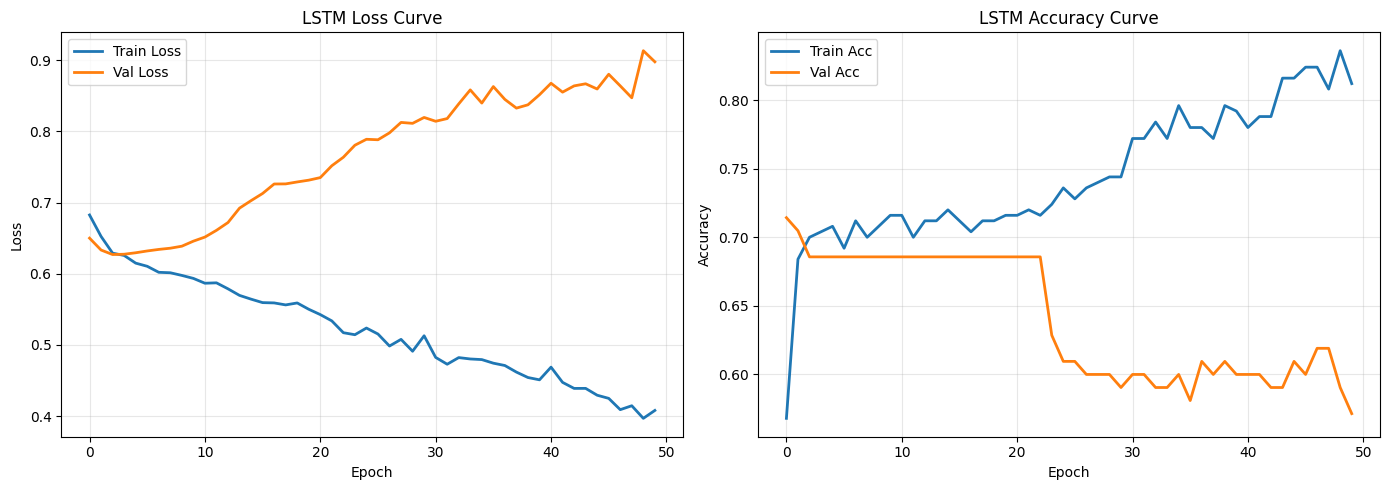

2. Training Kalman KO-PEP LSTM
LSTM Input Shape:
  Training Set: (151, 10, 9)
  Validation Set: (43, 10, 9)
  Training Label Distribution: Mean Reversion=139.0, Non-Reversion=12.0

Model Architecture:


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 10, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,657 (33.82 KB)

 Trainable params: 8,657 (33.82 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.6490 - loss: 0.6894 - val_accuracy: 0.8605 - val_loss: 0.6539
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8344 - loss: 0.6602 - val_accuracy: 0.9070 - val_loss: 0.6188
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9205 - loss: 0.6268 - val_accuracy: 0.9070 - val_loss: 0.5867
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9205 - loss: 0.5990 - val_accuracy: 0.9070 - val_loss: 0.5518
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9205 - loss: 0.5670 - val_accuracy: 0.9070 - val_loss: 0.5142
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9205 - loss: 0.5223 - val_accuracy: 0.9070 - val_loss: 0.4752
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9205 - loss: 0.4933 - val_accuracy: 0.9070 - val_loss: 0.4348
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9205 - loss: 0.4454 - val_accuracy: 0.9

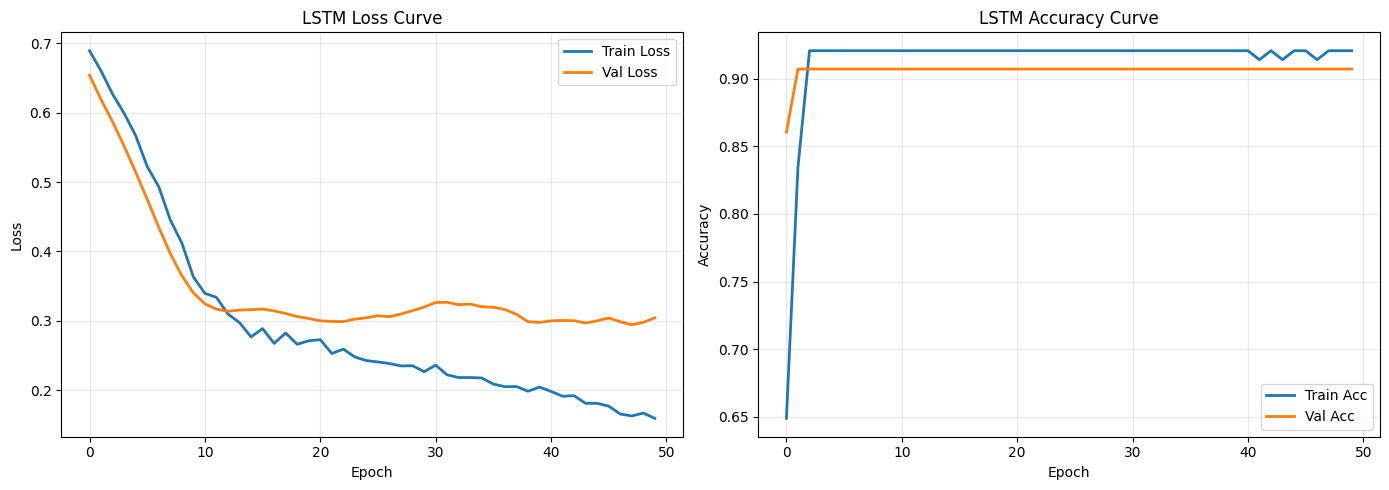

3. Training OLS XOM-CVX LSTM
LSTM Input Shape:
  Training Set: (213, 10, 9)
  Validation Set: (105, 10, 9)
  Training Label Distribution: Mean Reversion=136.0, Non-Reversion=77.0

Model Architecture:


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 10, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,657 (33.82 KB)

 Trainable params: 8,657 (33.82 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.5117 - loss: 0.6873 - val_accuracy: 0.5810 - val_loss: 0.6853
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6103 - loss: 0.6645 - val_accuracy: 0.6952 - val_loss: 0.6696
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6338 - loss: 0.6559 - val_accuracy: 0.6667 - val_loss: 0.6607
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6573 - loss: 0.6466 - val_accuracy: 0.6952 - val_loss: 0.6550
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6620 - loss: 0.6328 - val_accuracy: 0.7143 - val_loss: 0.6497
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6620 - loss: 0.6224 - val_accuracy: 0.7333 - val_loss: 0.6451
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6714 - loss: 0.6154 - val_accuracy: 0.7048 - val_loss: 0.6432
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6667 - loss: 0.6086 - val_accuracy: 0.66

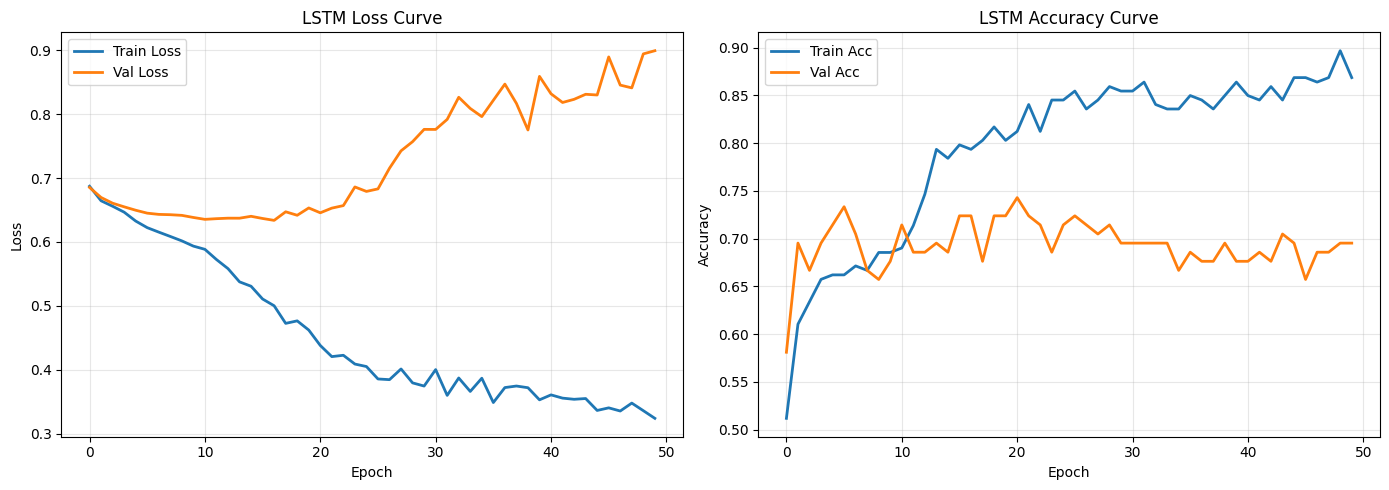

4. Training Kalman XOM-CVX LSTM
LSTM Input Shape:
  Training Set: (133, 10, 9)
  Validation Set: (40, 10, 9)
  Training Label Distribution: Mean Reversion=115.0, Non-Reversion=18.0

Model Architecture:


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 10, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,657 (33.82 KB)

 Trainable params: 8,657 (33.82 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.3383 - loss: 0.7161 - val_accuracy: 0.1000 - val_loss: 0.7129
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5489 - loss: 0.6938 - val_accuracy: 0.5750 - val_loss: 0.6923
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8120 - loss: 0.6783 - val_accuracy: 0.8000 - val_loss: 0.6787
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8421 - loss: 0.6685 - val_accuracy: 0.9250 - val_loss: 0.6665
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8571 - loss: 0.6544 - val_accuracy: 0.9250 - val_loss: 0.6549
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8647 - loss: 0.6429 - val_accuracy: 0.9250 - val_loss: 0.6420
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8647 - loss: 0.6285 - val_accuracy: 0.9250 - val_loss: 0.6281
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8647 - loss: 0.6083 - val_accuracy: 0.9

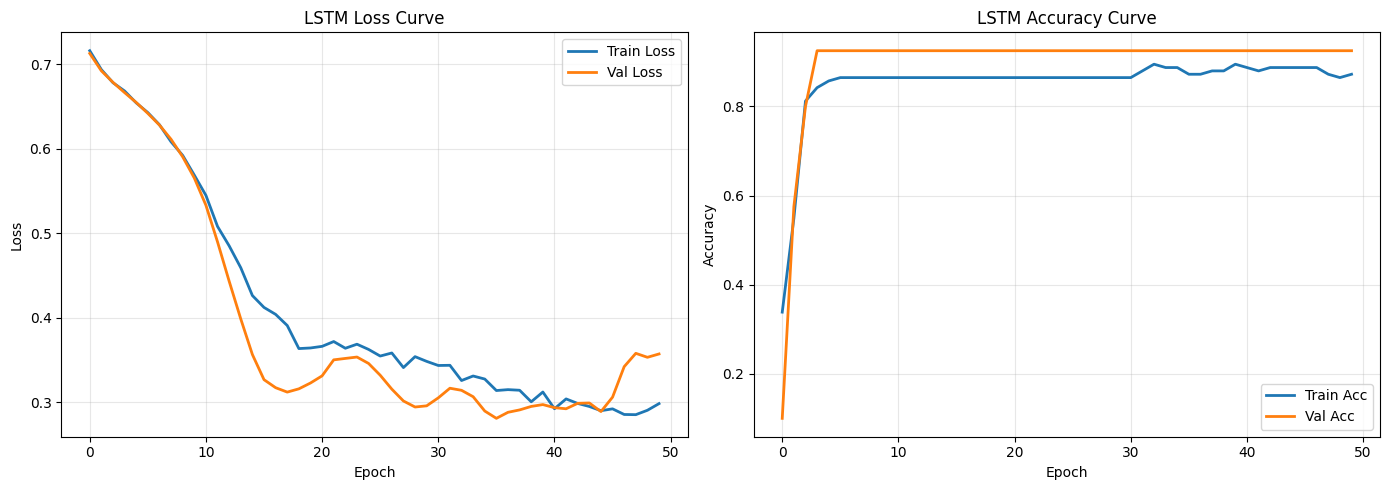

In [57]:
LOOKBACK = 10   # Use past 10 days of data for prediction
EPOCHS = 50     # Number of training epochs
BATCH_SIZE = 32


# 1. OLS KO-PEP LSTM
print("1. Training OLS KO-PEP LSTM")

# Prepare data
X_train_ols_ko_lstm, y_train_ols_ko_lstm = prepare_X_y(train_ols_ko, feature_columns)
X_val_ols_ko_lstm, y_val_ols_ko_lstm = prepare_X_y(val_ols_ko, feature_columns)
X_test_ols_ko_lstm, y_test_ols_ko_lstm = prepare_X_y(test_ols_ko, feature_columns)

# Standardization
scaler_ols_ko_lstm = StandardScaler()
X_train_ols_ko_lstm = scaler_ols_ko_lstm.fit_transform(X_train_ols_ko_lstm)
X_val_ols_ko_lstm = scaler_ols_ko_lstm.transform(X_val_ols_ko_lstm)
X_test_ols_ko_lstm = scaler_ols_ko_lstm.transform(X_test_ols_ko_lstm)

# Train model
lstm_ols_ko = train_lstm(
    X_train_ols_ko_lstm, y_train_ols_ko_lstm,
    X_val_ols_ko_lstm, y_val_ols_ko_lstm,
    lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH_SIZE
)


# 2. Kalman KO-PEP LSTM
print("2. Training Kalman KO-PEP LSTM")

X_train_kf_ko_lstm, y_train_kf_ko_lstm = prepare_X_y(train_kf_ko, feature_columns)
X_val_kf_ko_lstm, y_val_kf_ko_lstm = prepare_X_y(val_kf_ko, feature_columns)
X_test_kf_ko_lstm, y_test_kf_ko_lstm = prepare_X_y(test_kf_ko, feature_columns)

scaler_kf_ko_lstm = StandardScaler()
X_train_kf_ko_lstm = scaler_kf_ko_lstm.fit_transform(X_train_kf_ko_lstm)
X_val_kf_ko_lstm = scaler_kf_ko_lstm.transform(X_val_kf_ko_lstm)
X_test_kf_ko_lstm = scaler_kf_ko_lstm.transform(X_test_kf_ko_lstm)

lstm_kf_ko = train_lstm(
    X_train_kf_ko_lstm, y_train_kf_ko_lstm,
    X_val_kf_ko_lstm, y_val_kf_ko_lstm,
    lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH_SIZE
)


# 3. OLS XOM-CVX LSTM
print("3. Training OLS XOM-CVX LSTM")

X_train_ols_xom_lstm, y_train_ols_xom_lstm = prepare_X_y(train_ols_xom, feature_columns)
X_val_ols_xom_lstm, y_val_ols_xom_lstm = prepare_X_y(val_ols_xom, feature_columns)
X_test_ols_xom_lstm, y_test_ols_xom_lstm = prepare_X_y(test_ols_xom, feature_columns)

scaler_ols_xom_lstm = StandardScaler()
X_train_ols_xom_lstm = scaler_ols_xom_lstm.fit_transform(X_train_ols_xom_lstm)
X_val_ols_xom_lstm = scaler_ols_xom_lstm.transform(X_val_ols_xom_lstm)
X_test_ols_xom_lstm = scaler_ols_xom_lstm.transform(X_test_ols_xom_lstm)

lstm_ols_xom = train_lstm(
    X_train_ols_xom_lstm, y_train_ols_xom_lstm,
    X_val_ols_xom_lstm, y_val_ols_xom_lstm,
    lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH_SIZE
)


# 4. Kalman XOM-CVX LSTM
print("4. Training Kalman XOM-CVX LSTM")

X_train_kf_xom_lstm, y_train_kf_xom_lstm = prepare_X_y(train_kf_xom, feature_columns)
X_val_kf_xom_lstm, y_val_kf_xom_lstm = prepare_X_y(val_kf_xom, feature_columns)
X_test_kf_xom_lstm, y_test_kf_xom_lstm = prepare_X_y(test_kf_xom, feature_columns)

scaler_kf_xom_lstm = StandardScaler()
X_train_kf_xom_lstm = scaler_kf_xom_lstm.fit_transform(X_train_kf_xom_lstm)
X_val_kf_xom_lstm = scaler_kf_xom_lstm.transform(X_val_kf_xom_lstm)
X_test_kf_xom_lstm = scaler_kf_xom_lstm.transform(X_test_kf_xom_lstm)

lstm_kf_xom = train_lstm(
    X_train_kf_xom_lstm, y_train_kf_xom_lstm,
    X_val_kf_xom_lstm, y_val_kf_xom_lstm,
    lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH_SIZE
)


## **2.3 Generate LSTM prediction**

In [53]:
lstm_predictions = []

# 1. OLS KO-PEP LSTM
pred_lstm_ols_ko = generate_lstm_predictions(
    lstm_ols_ko, X_test_ols_ko_lstm, test_ols_ko, 'KO-PEP', 'OLS', lookback=LOOKBACK
)
lstm_predictions.append(pred_lstm_ols_ko)

# 2. Kalman KO-PEP LSTM
pred_lstm_kf_ko = generate_lstm_predictions(
    lstm_kf_ko, X_test_kf_ko_lstm, test_kf_ko, 'KO-PEP', 'Kalman', lookback=LOOKBACK
)
lstm_predictions.append(pred_lstm_kf_ko)

# 3. OLS XOM-CVX LSTM
pred_lstm_ols_xom = generate_lstm_predictions(
    lstm_ols_xom, X_test_ols_xom_lstm, test_ols_xom, 'XOM-CVX', 'OLS', lookback=LOOKBACK
)
lstm_predictions.append(pred_lstm_ols_xom)

# 4. Kalman XOM-CVX LSTM
pred_lstm_kf_xom = generate_lstm_predictions(
    lstm_kf_xom, X_test_kf_xom_lstm, test_kf_xom, 'XOM-CVX', 'Kalman', lookback=LOOKBACK
)
lstm_predictions.append(pred_lstm_kf_xom)


lstm_output = pd.concat(lstm_predictions, ignore_index=True)
lstm_output = lstm_output.sort_values(['pair', 'model', 'date']).reset_index(drop=True)


print("LSTM Prediction Summary:")
print(f"Total records: {len(lstm_output)}")
print(f"\nRecords per combination:")
print(lstm_output.groupby(['pair', 'model']).size())
print(f"\nSignal distribution per combination (ML_signal):")
print(lstm_output.groupby(['pair', 'model'])['ML_signal'].value_counts().unstack().fillna(0))

  KO-PEP OLS LSTM: Total 208 predictions
    Signal Distribution: ML_signal=1 count: 204, ML_signal=0 count: 4
  KO-PEP Kalman LSTM: Total 92 predictions
    Signal Distribution: ML_signal=1 count: 92, ML_signal=0 count: 0
  XOM-CVX OLS LSTM: Total 191 predictions
    Signal Distribution: ML_signal=1 count: 173, ML_signal=0 count: 18
  XOM-CVX Kalman LSTM: Total 78 predictions
    Signal Distribution: ML_signal=1 count: 78, ML_signal=0 count: 0
LSTM Prediction Summary:
Total records: 569

Records per combination:
pair     model      
KO-PEP   Kalman_LSTM     92
         OLS_LSTM       208
XOM-CVX  Kalman_LSTM     78
         OLS_LSTM       191
dtype: int64

Signal distribution per combination (ML_signal):
ML_signal               0      1
pair    model                   
KO-PEP  Kalman_LSTM   0.0   92.0
        OLS_LSTM      4.0  204.0
XOM-CVX Kalman_LSTM   0.0   78.0
        OLS_LSTM     18.0  173.0


## **2.4 Compile and export the signal file**

In [55]:
final_output = lstm_output.copy()

# Sort data
final_output = final_output.sort_values(['pair', 'model', 'date']).reset_index(drop=True)

print(f"Total LSTM records: {len(final_output)}")
print(f"\nRecords per combination:")
print(final_output.groupby(['pair', 'model']).size())

# Export to CSV
filename_final = 'ml_signals_lstm.csv'
final_output.to_csv(filename_final, index=False)

# Download file (Colab specific)
from google.colab import files
files.download(filename_final)

# Detailed signal distribution per model
for model_name in final_output['model'].unique():
    subset = final_output[final_output['model'] == model_name]
    count = len(subset)
    signal_1 = (subset['ML_signal'] == 1).sum()
    signal_0 = (subset['ML_signal'] == 0).sum()
    print(f"  {model_name}: {count} records, ML_signal=1: {signal_1}, ML_signal=0: {signal_0}")

Total LSTM records: 569

Records per combination:
pair     model      
KO-PEP   Kalman_LSTM     92
         OLS_LSTM       208
XOM-CVX  Kalman_LSTM     78
         OLS_LSTM       191
dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Kalman_LSTM: 170 records, ML_signal=1: 170, ML_signal=0: 0
  OLS_LSTM: 399 records, ML_signal=1: 377, ML_signal=0: 22
